# LIBRARIES AND DATA

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

In [2]:
df = pd.read_csv(r"C:\Users\Sergio\Desktop\SERGIO\DATA SCIENCE\GITHUB INGLES\data-science-portfolio\telco customer churn\data\Telco-Customer-Churn.csv")

# QUICK ANALYSIS

In [3]:
# Basic sanity checks
print("Shape:", df.shape)  # rows, columns
print("\nColumns:\n", df.columns.tolist())

# Standardize column names (optional but recommended)
#    Lowercase, replace spaces with underscores for safer references
df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(" ", "_")
              .str.replace("-", "_")
)

# Quick dtypes and missing values
print("\nDtypes:\n", df.dtypes.head(20))
print("\nMissing values (top 20):\n", df.isna().sum().sort_values(ascending=False).head(20))

# Target overview: churn distribution
#    Telco dataset usually uses "Yes"/"No" in 'churn'
if "churn" in df.columns:
    print("\nChurn distribution (counts):")
    print(df["churn"].value_counts(dropna=False))
    print("\nChurn distribution (%):")
    print((df["churn"].value_counts(normalize=True, dropna=False) * 100).round(2))
else:
    print("\n[Warning] Column 'churn' not found. Available columns:")
    print(df.columns.tolist())

# Peek first rows to verify parsing
df.head()

Shape: (7043, 21)

Columns:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Dtypes:
 customerid           object
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges         object
dtype: object

Missing values (top 20):
 customerid          0
gender        

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Data type overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   seniorcitizen     7043 non-null   int64  
 3   partner           7043 non-null   object 
 4   dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   object 
 7   multiplelines     7043 non-null   object 
 8   internetservice   7043 non-null   object 
 9   onlinesecurity    7043 non-null   object 
 10  onlinebackup      7043 non-null   object 
 11  deviceprotection  7043 non-null   object 
 12  techsupport       7043 non-null   object 
 13  streamingtv       7043 non-null   object 
 14  streamingmovies   7043 non-null   object 
 15  contract          7043 non-null   object 
 16  paperlessbilling  7043 non-null   object 


In [5]:
# Numerical summary
df.describe()

,seniorcitizen,tenure,monthlycharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Separate categories into categorical or numerical.

In [6]:
# Unique values per column (to detect categorical vs numerical)
unique_counts = df.nunique().sort_values(ascending=True)
print("\nUnique values per column:\n", unique_counts)


Unique values per column:
 gender                 2
seniorcitizen          2
partner                2
dependents             2
phoneservice           2
paperlessbilling       2
churn                  2
multiplelines          3
techsupport            3
streamingtv            3
onlinebackup           3
deviceprotection       3
streamingmovies        3
contract               3
onlinesecurity         3
internetservice        3
paymentmethod          4
tenure                73
monthlycharges      1585
totalcharges        6531
customerid          7043
dtype: int64


In [7]:
# Check for empty strings or special characters that might act as NaN
for col in df.columns:
    if df[col].dtype == 'object':
        missing_like = (df[col].astype(str).str.strip() == '').sum()
        if missing_like > 0:
            print(f"{col} has {missing_like} empty string values")

totalcharges has 11 empty string values


In [8]:
# Preview categorical variables
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("\nCategorical columns:\n", cat_cols)


Categorical columns:
 ['customerid', 'gender', 'partner', 'dependents', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'totalcharges', 'churn']


In [9]:
# Preview numerical variables
num_cols = df.select_dtypes(exclude='object').columns.tolist()
print("\nNumerical columns:\n", num_cols)


Numerical columns:
 ['seniorcitizen', 'tenure', 'monthlycharges']


In [ ]:
# Convert TotalCharges to numeric (it is object due to empty strings)
df["totalcharges"] = pd.to_numeric(df["totalcharges"], errors="coerce")

# Check remaining missing values
print("\nNull values in totalcharges:\n", df["totalcharges"].isna().sum())

# Verify SeniorCitizen looks binary
print(df["seniorcitizen"].value_counts())


Null values in totalcharges:
 11
seniorcitizen
0    5901
1    1142
Name: count, dtype: int64


In [ ]:
# Remove rows with missing TotalCharges (only 11 out of 7043)
df = df.dropna(subset=["totalcharges"])

# Confirm shape after cleaning
print("New shape:", df.shape)

New shape: (7032, 21)


# EDA

## Churn

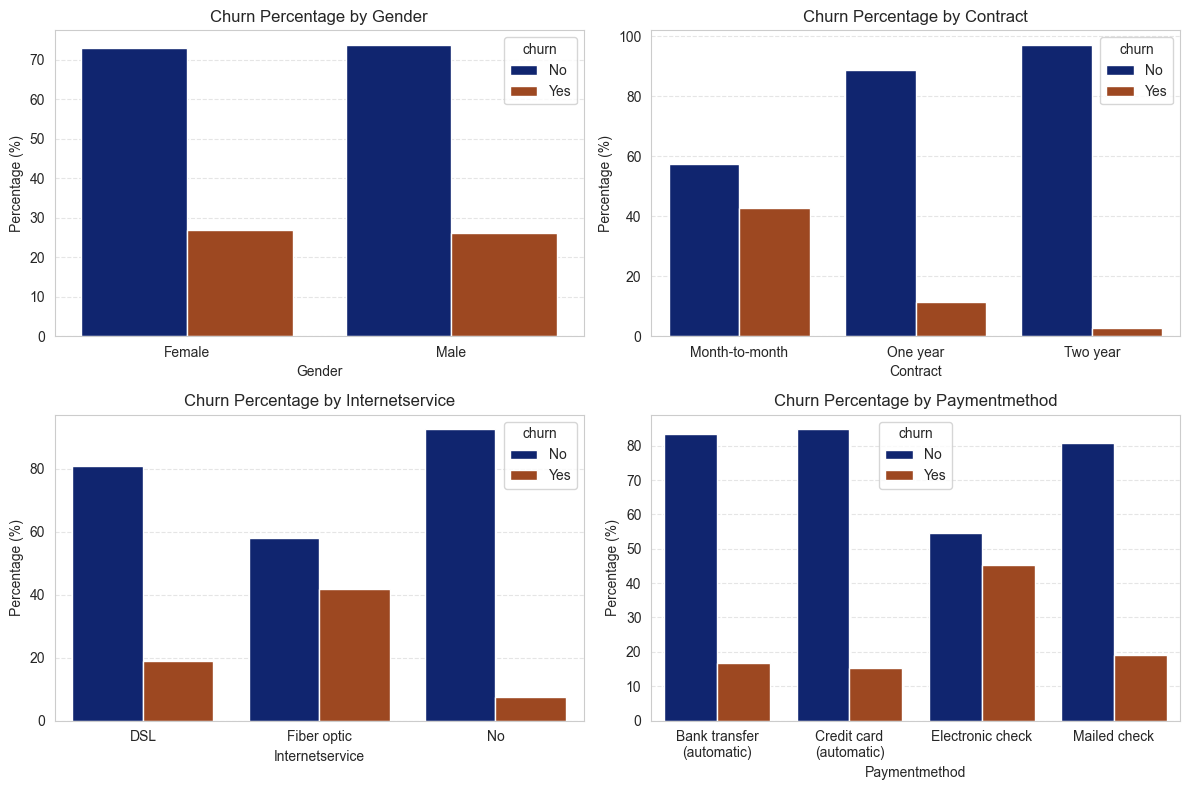

In [12]:
sns.set_style("whitegrid")
sns.set_palette("dark")

cat_vars = ["gender", "contract", "internetservice", "paymentmethod"]

plt.figure(figsize=(12, 8))

# Adjust Payment Method labels to avoid overlap
df["paymentmethod"] = (
    df["paymentmethod"]
    .replace({
        "Bank transfer (automatic)": "Bank transfer\n(automatic)",
        "Credit card (automatic)": "Credit card\n(automatic)"
    })
)


for i, var in enumerate(cat_vars, 1):
    plt.subplot(2, 2, i)
    
    # Calculate churn percentage within each category
    churn_percent = (
        df.groupby(var)["churn"]
          .value_counts(normalize=True)
          .rename("percent")
          .mul(100)
          .reset_index()
    )
    
    # Barplot with percentage values
    sns.barplot(data=churn_percent, x=var, y="percent", hue="churn")
    plt.title(f"Churn Percentage by {var.capitalize()}")
    plt.ylabel("Percentage (%)")
    plt.xlabel(var.capitalize())
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()

plt.show()

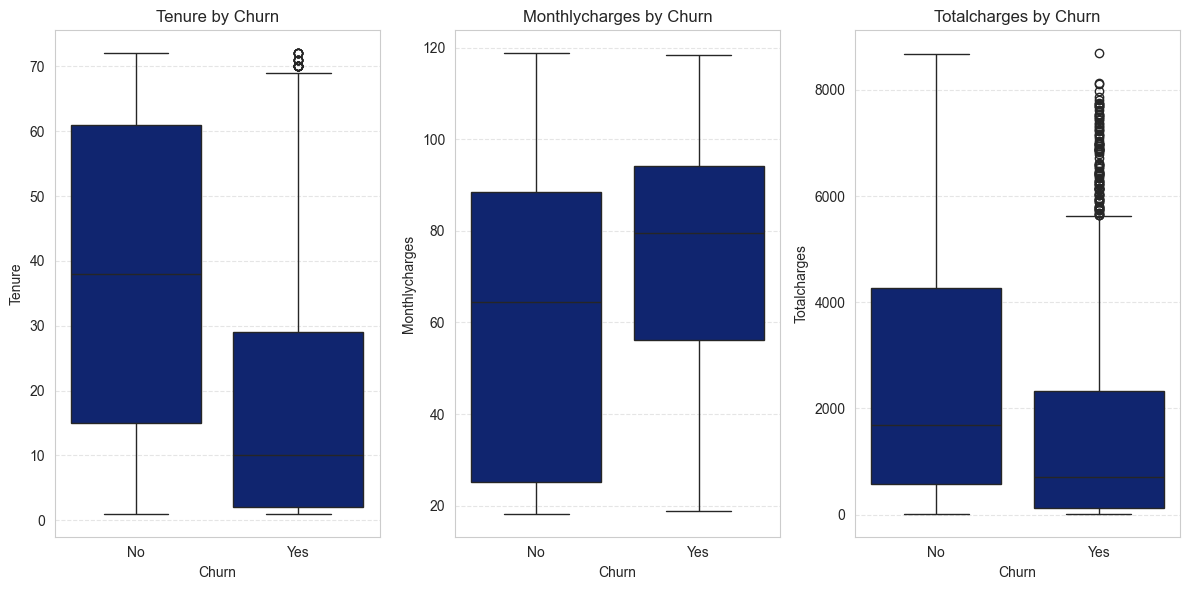

In [13]:
num_vars = ["tenure", "monthlycharges", "totalcharges"]

plt.figure(figsize=(12, 6))

for i, var in enumerate(num_vars, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(data=df, x="churn", y=var)
    plt.title(f"{var.capitalize()} by Churn")
    plt.xlabel("Churn")
    plt.ylabel(var.capitalize())
    plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## Collinearity

### Correlation matrix

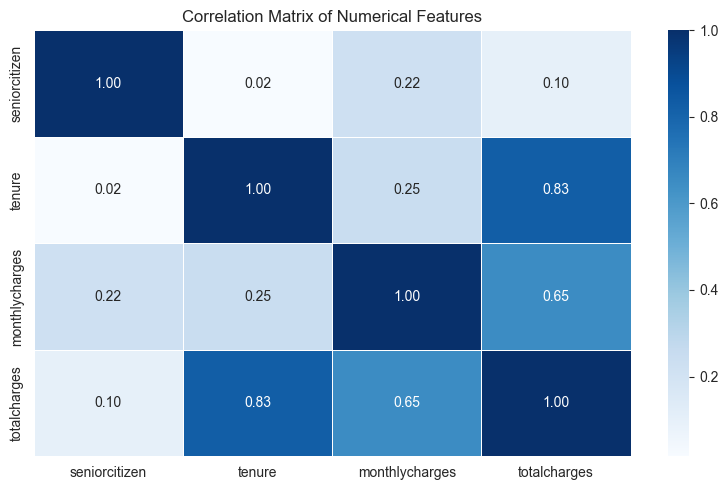

In [14]:
# Numeric correlation analysis
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Compute correlation matrix
corr = numeric_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

### Variance Inflation Factor (VIF)

In [15]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=["int64", "float64"]).copy()

# Add constant (required for VIF calculation)
X = add_constant(numeric_df)

# Compute VIF for each variable
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display results excluding the constant
vif_data = vif_data[vif_data["Feature"] != "const"]
print(vif_data)

          Feature       VIF
1   seniorcitizen  1.054455
2          tenure  5.847215
3  monthlycharges  3.314481
4    totalcharges  9.543891


We will remove the ‘totalcharges’ column because it provides redundant information and may confuse future models.

In [16]:
# Remove the highly correlated variable
df = df.drop(columns=["totalcharges"])

# RANDOM FOREST

## Prepare the variables and the dataset

In [17]:
# Encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

# Check the shape and preview
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (7032, 7061)


,seniorcitizen,tenure,monthlycharges,customerid_0003-MKNFE,customerid_0004-TLHLJ,customerid_0011-IGKFF,customerid_0013-EXCHZ,customerid_0013-MHZWF,customerid_0013-SMEOE,customerid_0014-BMAQU,...,streamingtv_Yes,streamingmovies_No internet service,streamingmovies_Yes,contract_One year,contract_Two year,paperlessbilling_Yes,paymentmethod_Credit card\n(automatic),paymentmethod_Electronic check,paymentmethod_Mailed check,churn_Yes
0,0,1,29.85,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,True


In [18]:
# Target and features
y = df_encoded["churn_Yes"]
X = df_encoded.drop(columns=["churn_Yes"])

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (5625, 7060), Test shape: (1407, 7060)


## Model

Accuracy: 0.7342
ROC-AUC: 0.8019

Classification Report:

              precision    recall  f1-score   support

       False       0.73      1.00      0.85      1033
        True       0.00      0.00      0.00       374

    accuracy                           0.73      1407
   macro avg       0.37      0.50      0.42      1407
weighted avg       0.54      0.73      0.62      1407



c:\Users\Sergio\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sergio\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sergio\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

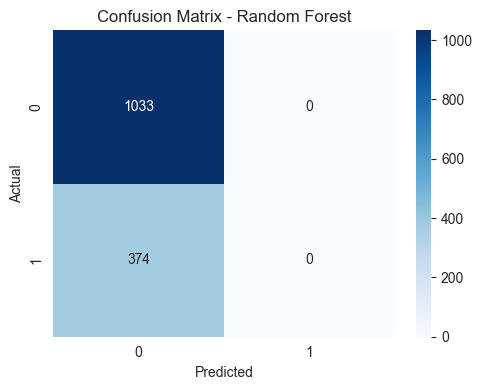

In [20]:
# Initialize the model
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=2,
    random_state=42
)

# Fit the model
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### Re-Train

Accuracy: 0.7889
ROC-AUC: 0.8228

Classification Report:

              precision    recall  f1-score   support

       False       0.83      0.89      0.86      1033
        True       0.63      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



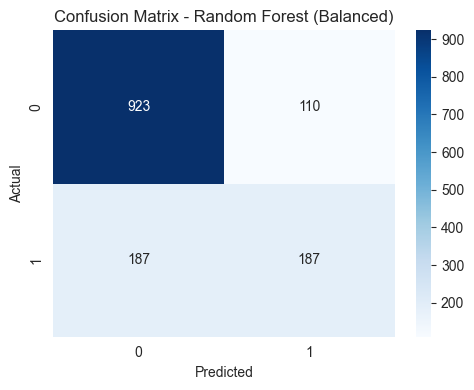

In [21]:
# Train Random Forest with balanced class weights
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf_balanced.fit(X_train, y_train)

# Predictions
y_pred_bal = rf_balanced.predict(X_test)
y_prob_bal = rf_balanced.predict_proba(X_test)[:, 1]

# Evaluation
accuracy_bal = accuracy_score(y_test, y_pred_bal)
roc_auc_bal = roc_auc_score(y_test, y_prob_bal)

print(f"Accuracy: {accuracy_bal:.4f}")
print(f"ROC-AUC: {roc_auc_bal:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_bal))

# Confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_bal), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest (Balanced)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


                             Feature  Importance
1                             tenure    0.116961
2                     monthlycharges    0.085875
7055               contract_Two year    0.040791
7058  paymentmethod_Electronic check    0.030638
7040     internetservice_Fiber optic    0.029186
7054               contract_One year    0.026596
7043              onlinesecurity_Yes    0.025033
7049                 techsupport_Yes    0.023457
7056            paperlessbilling_Yes    0.018909
7035                     partner_Yes    0.017876
7045                onlinebackup_Yes    0.017207
7034                     gender_Male    0.017014
7036                  dependents_Yes    0.015690
7047            deviceprotection_Yes    0.014212
0                      seniorcitizen    0.013170


C:\Users\Sergio\AppData\Local\Temp\ipykernel_9716\844016961.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_importance.head(15), x="Importance", y="Feature", palette="dark")


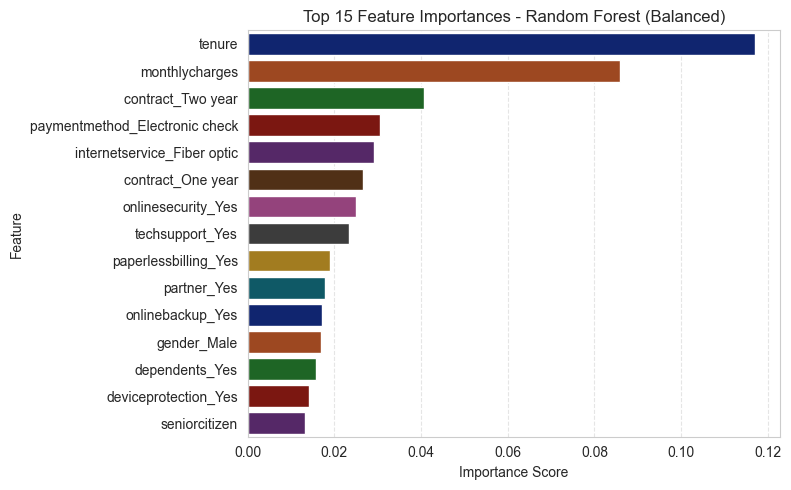

In [22]:
# Feature importance from the balanced Random Forest model
importances = rf_balanced.feature_importances_

# Create a DataFrame with feature names and importance values
feat_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Display top 15 features
print(feat_importance.head(15))

# Plot feature importance
plt.figure(figsize=(8,5))
sns.barplot(data=feat_importance.head(15), x="Importance", y="Feature", palette="dark")
plt.title("Top 15 Feature Importances - Random Forest (Balanced)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


Our model is learning business patterns well:

Tenure and contract type are the most decisive structural factors.

Monthly fees and complementary services explain much of the remaining behaviour.

This indicates that the model, although not yet perfect in terms of metrics, already correctly understands the most logical relationships — which means we can confidently move on to the next step:
optimising hyperparameters to improve recall without sacrificing accuracy.

### GridSearchCV tunning

In [25]:
# Use same training data: X_train, y_train, X_test, y_test

# Base model with class balancing
rf_base = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Hyperparameter grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"]
}

# Stratified CV to keep churn proportion in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid search using ROC-AUC as main metric
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Run grid search
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV ROC-AUC: 0.8383842023856761


Accuracy (test): 0.7797
ROC-AUC (test): 0.8289

Classification Report:

              precision    recall  f1-score   support

       False       0.87      0.83      0.85      1033
        True       0.58      0.64      0.61       374

    accuracy                           0.78      1407
   macro avg       0.72      0.74      0.73      1407
weighted avg       0.79      0.78      0.78      1407



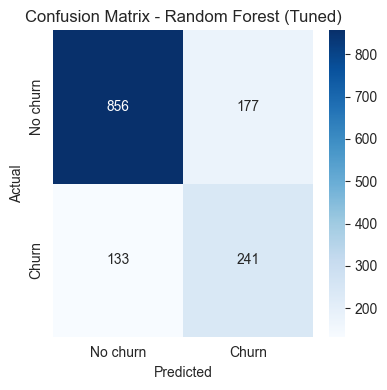

In [26]:
# Best model from grid search
best_rf = grid_search.best_estimator_

# Fit on full training set
best_rf.fit(X_train, y_train)

# Predictions and probabilities
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)

print(f"Accuracy (test): {acc:.4f}")
print(f"ROC-AUC (test): {roc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No churn", "Churn"],
            yticklabels=["No churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest (Tuned)")
plt.tight_layout()
plt.show()

# GRADIENT BOOST

Accuracy (test) - Gradient Boosting: 0.7982
ROC-AUC (test) - Gradient Boosting: 0.8415

Classification Report - Gradient Boosting:

              precision    recall  f1-score   support

       False       0.84      0.90      0.87      1033
        True       0.65      0.52      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



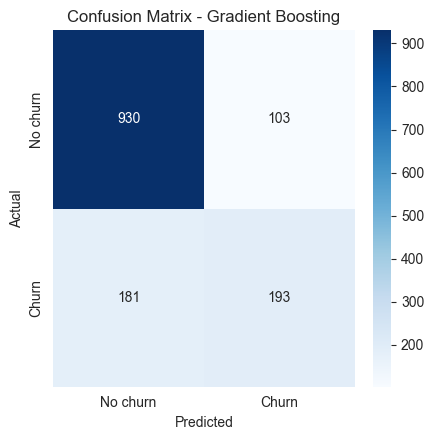

In [28]:
#  Train Gradient Boosting model
gb_clf = GradientBoostingClassifier(
    n_estimators=200,      # number of boosting stages
    learning_rate=0.05,    # shrinkage rate
    max_depth=3,           # depth of individual trees
    subsample=0.8,         # stochastic gradient boosting
    random_state=42
)

gb_clf.fit(X_train, y_train)

#  Predictions and probabilities
y_pred_gb = gb_clf.predict(X_test)
y_proba_gb = gb_clf.predict_proba(X_test)[:, 1]

#  Evaluation metrics
acc_gb = accuracy_score(y_test, y_pred_gb)
roc_auc_gb = roc_auc_score(y_test, y_proba_gb)

print(f"Accuracy (test) - Gradient Boosting: {acc_gb:.4f}")
print(f"ROC-AUC (test) - Gradient Boosting: {roc_auc_gb:.4f}\n")

print("Classification Report - Gradient Boosting:\n")
print(classification_report(y_test, y_pred_gb, target_names=["False", "True"]))

#  Confusion matrix
cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(4.5, 4.5))
sns.heatmap(
    cm_gb,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=["No churn", "Churn"],
    yticklabels=["No churn", "Churn"]
)
plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# CONCLUSION OF THE MODELS

<Figure size 800x400 with 0 Axes>

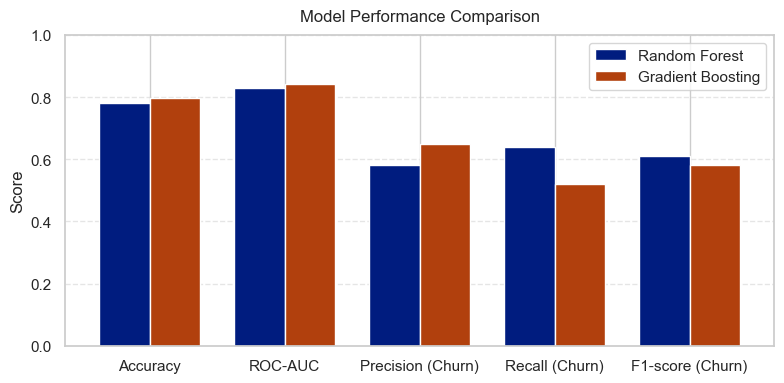

In [32]:
# Metrics for comparison (from the reports)
metrics = {
    "Accuracy": [0.7797, 0.7982],
    "ROC-AUC": [0.8289, 0.8415],
    "Precision (Churn)": [0.58, 0.65],
    "Recall (Churn)": [0.64, 0.52],
    "F1-score (Churn)": [0.61, 0.58]
}

# Create DataFrame
results_df = pd.DataFrame(metrics, index=["Random Forest", "Gradient Boosting"]).T

#  Adjusted model comparison chart
sns.set(style="whitegrid", palette="dark")

plt.figure(figsize=(8,4))
ax = results_df.plot(kind="bar", figsize=(8,4), width=0.75)

# Title and labels
plt.title("Model Performance Comparison", fontsize=12, pad=10)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)  # Keep metric labels horizontal

# Grid and legend
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="", loc="upper right", bbox_to_anchor=(1, 1))  # Move legend up

plt.tight_layout()
plt.show()

Model Comparison Analysis

The chart above compares the performance of the two classification models — Random Forest and Gradient Boosting — across key evaluation metrics.

Both models achieved similar overall performance, with Gradient Boosting slightly outperforming in Accuracy (0.80) and ROC-AUC (0.84), indicating a stronger overall ability to distinguish between churn and non-churn customers.

However, the Random Forest model achieved higher Recall (0.64 vs. 0.52), meaning it identified a larger proportion of customers who actually churned. On the other hand, Gradient Boosting reached better Precision (0.65 vs. 0.58), showing it was more reliable when predicting churn cases, despite missing more actual churners.

From a business perspective, the choice between the two models depends on strategic priorities:

If the goal is to minimize false negatives and proactively retain more at-risk customers, Random Forest is more suitable.

If the focus is on accurate targeting to avoid overreacting to false churn predictions, Gradient Boosting would be preferable.

Overall, the results highlight that model performance is well-balanced, and the predictive capability is strong enough to guide targeted retention strategies.

# TEST

In [35]:
# Recreate and train tuned model
gb_best = GradientBoostingClassifier(
    learning_rate=0.05,
    n_estimators=200,
    max_depth=3,
    random_state=42
)
gb_best.fit(X_train, y_train)

print("Model re-trained successfully as gb_best")

Model re-trained successfully as gb_best


Test Accuracy: 0.7960
Test ROC-AUC: 0.8413

Classification Report (Test Data):

              precision    recall  f1-score   support

       False       0.83      0.91      0.87      1033
        True       0.65      0.49      0.56       374

    accuracy                           0.80      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.78      0.80      0.79      1407



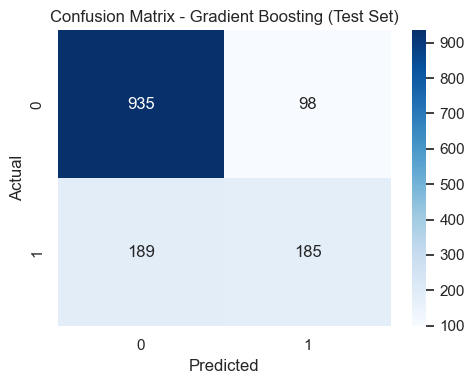

In [36]:
# Predictions on test data
y_test_pred = gb_best.predict(X_test)
y_test_proba = gb_best.predict_proba(X_test)[:, 1]

# Metrics
acc_test = accuracy_score(y_test, y_test_pred)
roc_auc_test = roc_auc_score(y_test, y_test_proba)

print(f"Test Accuracy: {acc_test:.4f}")
print(f"Test ROC-AUC: {roc_auc_test:.4f}")
print("\nClassification Report (Test Data):\n")
print(classification_report(y_test, y_test_pred))

#  Confusion matrix visualization
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_test_pred),
            annot=True, fmt="d", cmap="Blues", cbar=True)
plt.title("Confusion Matrix - Gradient Boosting (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## ROC and Precision-Recall Curves

c:\Users\Sergio\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


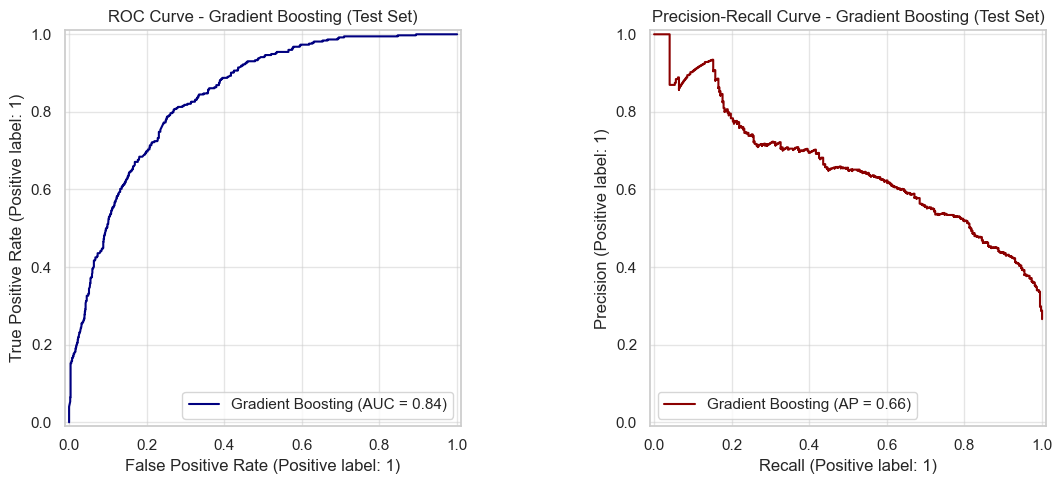

In [38]:
# Get probabilities for the positive class (Churn)
y_proba = gb_best.predict_proba(X_test)[:, 1]

# Create figure
plt.figure(figsize=(12,5))

# ROC Curve
plt.subplot(1,2,1)
roc_display = RocCurveDisplay.from_predictions(y_test, y_proba, name="Gradient Boosting", color="navy", ax=plt.gca())
plt.title("ROC Curve - Gradient Boosting (Test Set)")
plt.grid(alpha=0.5)

# Precision-Recall Curve
plt.subplot(1,2,2)
pr_display = PrecisionRecallDisplay.from_predictions(y_test, y_proba, name="Gradient Boosting", color="darkred", ax=plt.gca())
plt.title("Precision-Recall Curve - Gradient Boosting (Test Set)")
plt.grid(alpha=0.5)

plt.tight_layout()
plt.show()

ROC and Precision-Recall Analysis

The ROC Curve (left) shows the trade-off between the true positive rate and the false positive rate.
With an AUC of 0.84, the model demonstrates strong discriminative capability — it effectively separates customers likely to churn from those who will stay.
The curve’s steep ascent near the y-axis indicates that the model achieves high recall with relatively few false positives, which is a desirable pattern in churn prediction.

The Precision-Recall Curve (right) provides a more detailed view for the minority “Churn” class.
An Average Precision (AP) of 0.66 suggests that the model maintains a good balance between identifying actual churners and minimizing false alarms.
This performance is suitable for real-world churn management scenarios, where false positives (targeting loyal customers) are less costly than false negatives (failing to detect customers about to leave).

In summary, the Gradient Boosting model achieves a solid generalization balance:
it detects a meaningful portion of churners while keeping overall prediction accuracy high — making it a reliable foundation for customer retention initiatives.

C:\Users\Sergio\AppData\Local\Temp\ipykernel_9716\455794276.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gb_importances, y="Feature", x="Importance", palette="dark")


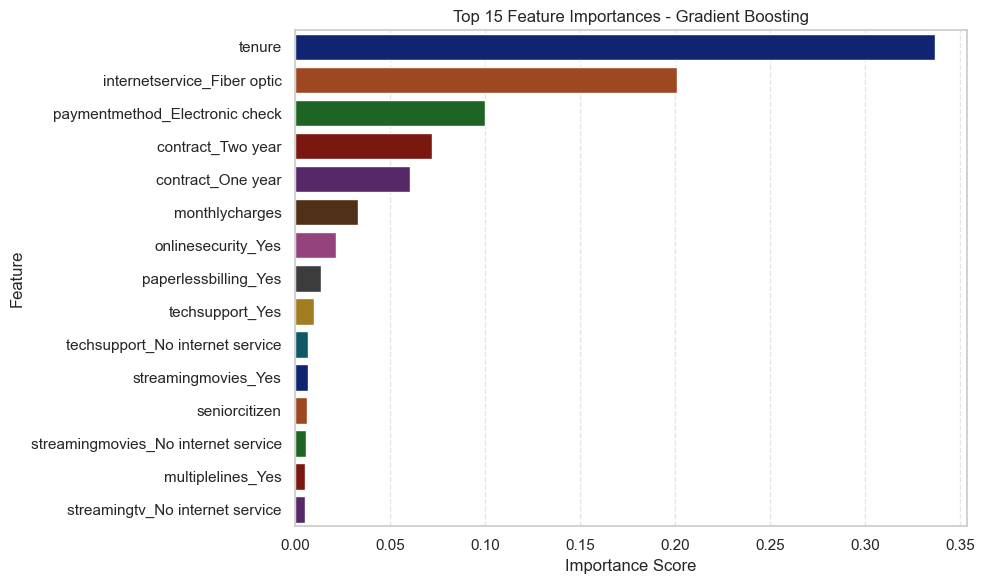

In [39]:
# Extract feature importances
gb_importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb_best.feature_importances_
}).sort_values(by="Importance", ascending=False).head(15)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(data=gb_importances, y="Feature", x="Importance", palette="dark")

plt.title("Top 15 Feature Importances - Gradient Boosting")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Feature Importance Analysis

The Gradient Boosting model reveals that customer tenure is by far the most influential factor in predicting churn.
Clients with shorter relationships to the company are significantly more likely to leave, highlighting the importance of early-stage engagement and retention strategies.

The second most relevant variable is internet service type, particularly Fiber optic.
Customers using fiber connections show a higher churn tendency, possibly due to stronger competition or pricing differences compared to DSL users.

Payment method also plays a major role: users paying through Electronic check churn more often, a pattern consistent with lower customer satisfaction and weaker commitment levels.
Conversely, those on long-term contracts (One year / Two year) exhibit lower churn, reinforcing the stabilizing effect of contractual loyalty.

Finally, features such as monthly charges, online security, and technical support contribute moderately, suggesting that perceived value and service quality still influence the decision to stay.

In summary, churn is primarily driven by tenure, service type, and payment behavior, which together describe a profile of customers more prone to switching providers early in their relationship or under specific service conditions.

# Final Conclusions and Business Insights

This project focused on analyzing customer churn behavior using the Telco Customer Churn dataset.
After extensive exploration and data cleaning, several clear behavioral patterns were identified:

Customers with shorter tenure are the most likely to churn, confirming that the early months of a client’s relationship are critical for retention.

Fiber optic users and those who pay through Electronic check represent the highest-risk segments, suggesting potential dissatisfaction or competitive sensitivity.

Long-term contracts (One-year or Two-year) strongly reduce churn, emphasizing the value of subscription stability and customer commitment.

Service-related features such as Online Security, Tech Support, and Paperless Billing also play measurable roles in influencing retention, likely linked to convenience and perceived reliability.

From a modeling perspective, the Gradient Boosting algorithm delivered the best overall performance:

Accuracy: 79.6%

ROC-AUC: 0.84

Precision (Churn): 0.65

Recall (Churn): 0.49

Although recall remains moderate, the model effectively distinguishes high-risk customers and provides actionable insights for targeted retention strategies.

Business Impact:
By focusing on customers with low tenure, fiber optic plans, and electronic check payments, retention campaigns could be optimized to prevent early churn and improve customer lifetime value.

Future improvements may include fine-tuning threshold optimization, incorporating customer feedback metrics, or integrating SHAP-based explainability to enhance interpretability for business stakeholders.

In [40]:
# Load raw dataset
df_raw = pd.read_csv(r"C:\Users\Sergio\Desktop\SERGIO\DATA SCIENCE\GITHUB INGLES\data-science-portfolio\telco customer churn\data\Telco-Customer-Churn.csv")

# Clean totalcharges: convert to numeric and drop invalid rows
df = df_raw.copy()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["TotalCharges"])

# Make sure numeric columns have numeric dtypes
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

# Make SeniorCitizen more interpretable
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

# Keep churn as Yes/No for easier filtering in Power BI
# (the original dataset already has it like this, so no change needed)
df["Churn"] = df["Churn"].astype("category")

# Optional: set some columns as categories (helps in Power BI slicers, but not required)
cat_cols = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod", "Churn"
]
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")

# Save clean dataset for Power BI
output_path = "../data/telco_churn_clean_powerbi.csv"
df.to_csv(output_path, index=False)

output_path, df.shape


('../data/telco_churn_clean_powerbi.csv', (7032, 21))